## Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

## Load Dataset

In [4]:
df = pd.read_csv('../Data/raw/PhiUSIIL_Phishing_URL_Dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


## Preprocessing

### Drop kolom Metadata

In [7]:
# Kolom yang perlu di-drop (metadata, bukan fitur)
metadata_cols = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']

df_model = df.drop(columns=metadata_cols)
print(f'Shape setelah drop metadata: {df_model.shape}')
print(f'Kolom tersisa: \n {df_model.columns.tolist()}')


Shape setelah drop metadata: (235795, 51)
Kolom tersisa: 
 ['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


### Features dan Target

In [8]:
X = df_model.drop(columns=['label'])
y = df_model['label']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nTarget distribution:\n{y.value_counts(normalize=True)}')


Features shape: (235795, 50)
Target shape: (235795,)

Target distribution:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64


### Training Data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,   
    stratify=y          
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nTraining target distribution:\n{y_train.value_counts(normalize=True)}')
print(f'\nTest target distribution:\n{y_test.value_counts(normalize=True)}')


Training set: (188636, 50)
Test set: (47159, 50)

Training target distribution:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64

Test target distribution:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64


### Feature Scaling

In [10]:
scaler = StandardScaler()

# Fit hanya pada training data, transform keduanya
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

print('Scaling selesai.')
print(f'Mean training (sample): {X_train_scaled.iloc[:, :3].mean().values}')
print(f'Std training (sample): {X_train_scaled.iloc[:, :3].std().values}')


Scaling selesai.
Mean training (sample): [-7.39787704e-17 -1.73345367e-16 -4.67075740e-18]
Std training (sample): [1.00000265 1.00000265 1.00000265]


### Opsional: hapus fitur dengan korelasi tinggi

In [ ]:
correlation_matrix = X_train_scaled.corr().abs()
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
high_corr_features = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'Fitur dengan korelasi > 0.95: {high_corr_features}')

# Bisa pilih untuk drop atau tidak
# X_train_scaled = X_train_scaled.drop(columns=high_corr_features)
# X_test_scaled = X_test_scaled.drop(columns=high_corr_features)


Fitur dengan korelasi > 0.95: ['URLTitleMatchScore']


## Modeling

### Definisi Model & Fungsi Evaluasi

In [12]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Evaluasi model dan return metrics."""
    # Training
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Probabilities (untuk ROC AUC)
    if hasattr(model, 'predict_proba'):
        y_proba_test = model.predict_proba(X_test)[:, 1]
    else:
        y_proba_test = model.decision_function(X_test)
    
    # Metrics
    metrics = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_pred_train),
        'Test Accuracy': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test),
        'F1-Score': f1_score(y_test, y_pred_test),
        'ROC AUC': roc_auc_score(y_test, y_proba_test),
    }
    
    return metrics, y_pred_test, y_proba_test


#### Definisi Kandidat Model

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}


### Training & Evaluasi Semua Model

In [14]:
results = []
predictions = {}

for name, model in models.items():
    print(f'Training {name}...')
    metrics, y_pred, y_proba = evaluate_model(
        model, X_train_scaled, X_test_scaled, y_train, y_test, name
    )
    results.append(metrics)
    predictions[name] = {'y_pred': y_pred, 'y_proba': y_proba}
    print(f'  Test Accuracy: {metrics["Test Accuracy"]:.4f} | F1: {metrics["F1-Score"]:.4f} | AUC: {metrics["ROC AUC"]:.4f}')
    print()

# Summary table
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
results_df = results_df.sort_values('F1-Score', ascending=False)
print('=== Model Comparison ===')
results_df


Training Logistic Regression...
  Test Accuracy: 0.9999 | F1: 0.9999 | AUC: 1.0000

Training Decision Tree...
  Test Accuracy: 1.0000 | F1: 1.0000 | AUC: 1.0000

Training Random Forest...
  Test Accuracy: 1.0000 | F1: 1.0000 | AUC: 1.0000

Training Gradient Boosting...
  Test Accuracy: 1.0000 | F1: 1.0000 | AUC: 1.0000

=== Model Comparison ===


,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,,
Decision Tree,1.000000,1.000000,1.000000,1.0,1.000000,1.0
Random Forest,1.000000,1.000000,1.000000,1.0,1.000000,1.0
Gradient Boosting,1.000000,1.000000,1.000000,1.0,1.000000,1.0
Logistic Regression,0.999899,0.999873,0.999778,1.0,0.999889,1.0


### Visualisasi Perbandingan Model

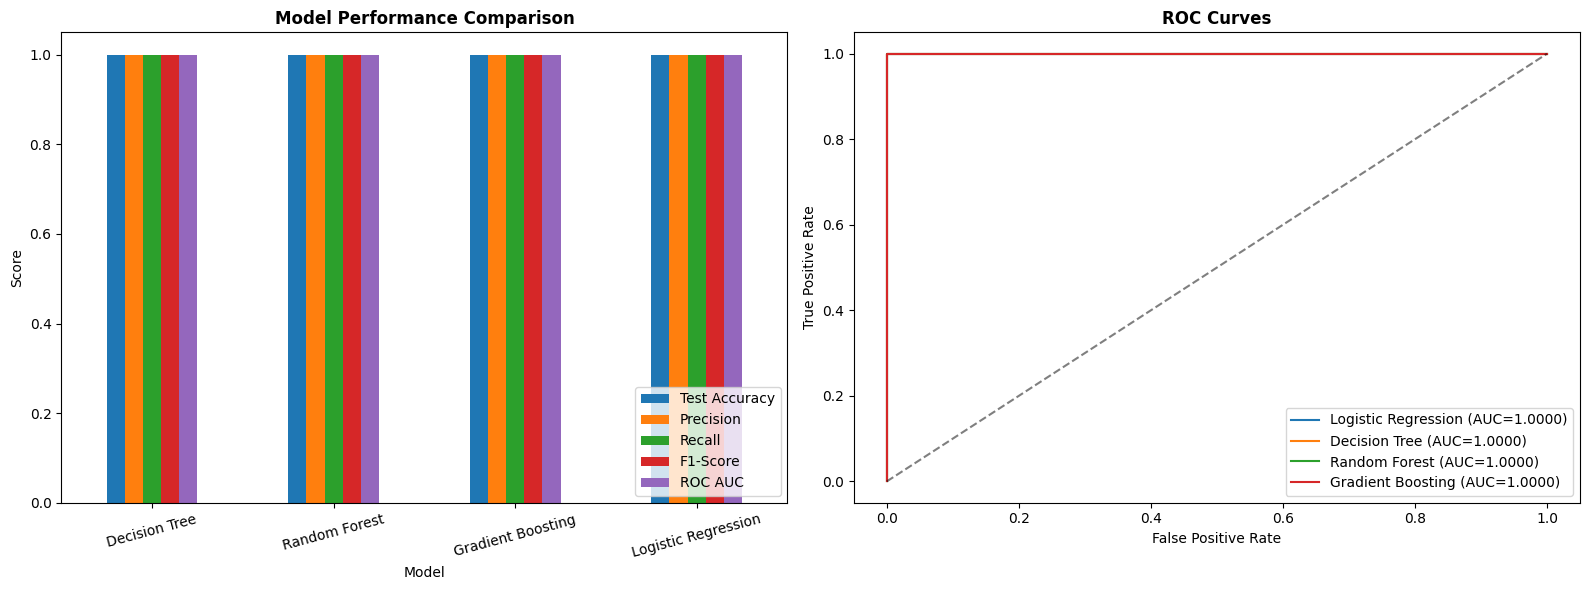

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart - metrics comparison
metrics_to_plot = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
results_df[metrics_to_plot].plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_title('Model Performance Comparison', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')

# ROC Curves
for name in predictions:
    fpr, tpr, _ = roc_curve(y_test, predictions[name]['y_proba'])
    auc = roc_auc_score(y_test, predictions[name]['y_proba'])
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../Artifacts/figures/10_model_comparison.png', bbox_inches='tight')
plt.show()


#### Confusion Matrix untuk Model Terbaik

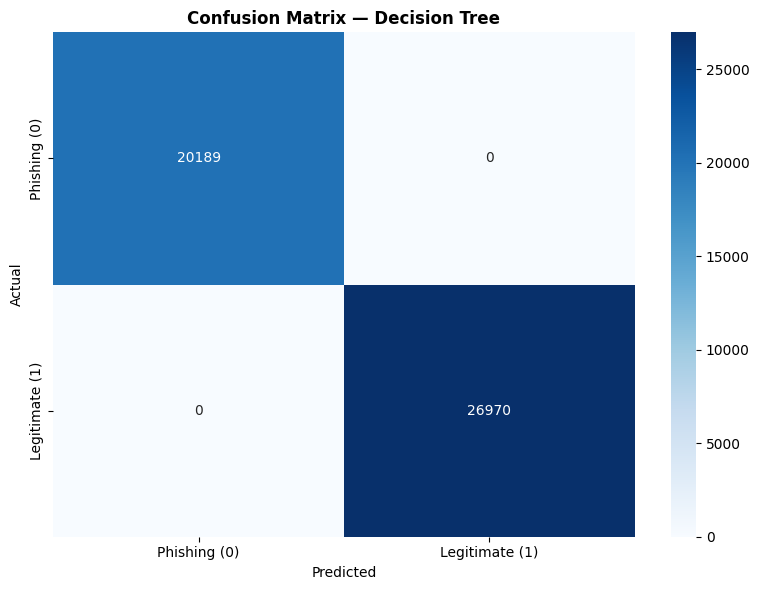


Classification Report — Decision Tree:
              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [ ]:
best_model_name = results_df.index[0]  # Model dengan F1 terbaik
y_pred_best = predictions[best_model_name]['y_pred']

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Phishing (0)', 'Legitimate (1)'],
            yticklabels=['Phishing (0)', 'Legitimate (1)'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('../Artifacts/figures/11_confusion_matrix_best.png', bbox_inches='tight')
plt.show()

print(f'\nClassification Report — {best_model_name}:')
print(classification_report(y_test, y_pred_best, 
                            target_names=['Phishing', 'Legitimate']))


### Feature Importance (jika tree-based model)

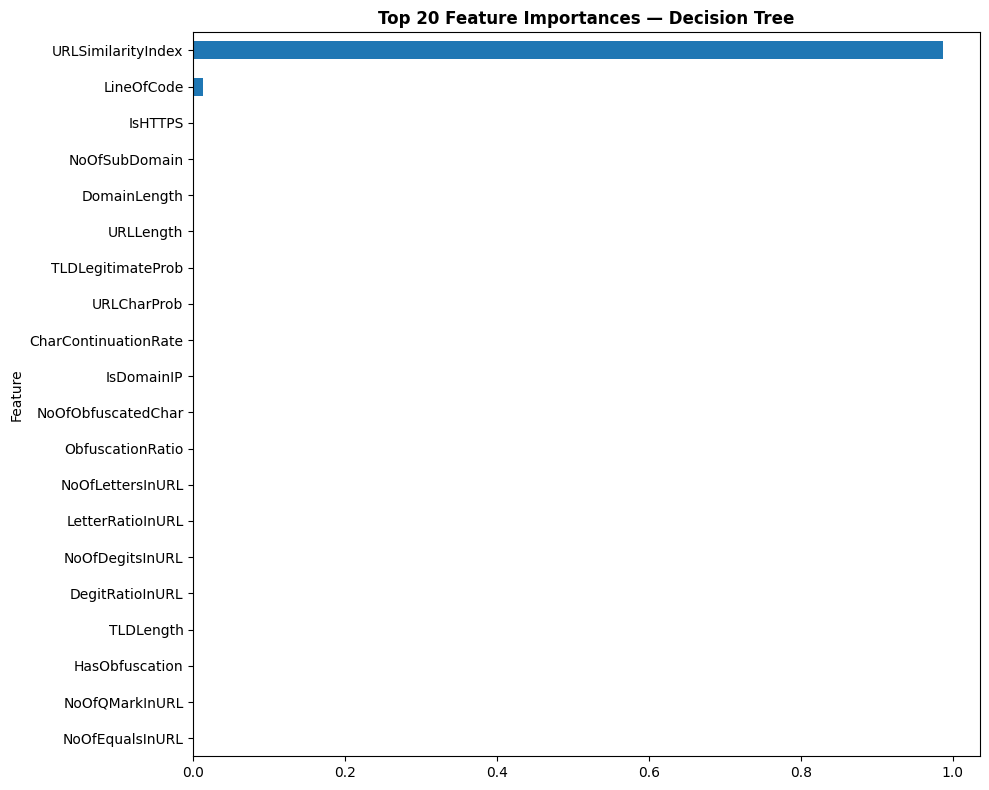

In [17]:
if hasattr(models[best_model_name], 'feature_importances_'):
    importances = models[best_model_name].feature_importances_
    feature_imp = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_n = 20
    feature_imp.head(top_n).plot(
        kind='barh', x='Feature', y='Importance', ax=ax, legend=False
    )
    ax.set_title(f'Top {top_n} Feature Importances — {best_model_name}', fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('../Artifacts/figures/12_feature_importance.png', bbox_inches='tight')
    plt.show()
    

### Simpan Model 

In [ ]:
# import os

# # Buat direktori jika belum ada
# os.makedirs('../Artifacts/models', exist_ok=True)

# # Simpan model terbaik
# best_model = models[best_model_name]
# model_path = f'../Artifacts/models/best_model_{best_model_name.lower().replace(" ", "_")}.pkl'
# with open(model_path, 'wb') as f:
#     pickle.dump(best_model, f)

# # Simpan scaler
# with open('../Artifacts/models/scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# # Simpan results
# results_df.to_csv('../Artifacts/models/model_comparison_results.csv')

# print(f'Model terbaik ({best_model_name}) dan scaler berhasil disimpan!')


Model terbaik (Decision Tree) dan scaler berhasil disimpan!
